In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
def seed_everything(seed=42):
    import os
    import random
    import numpy as np
    import tensorflow as tf

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
    os.environ["TF_NUM_INTEROP_THREADS"] = "1"

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)

    tf.config.optimizer.set_jit(False)


seed_everything(42)

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from math import sqrt
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import random
from dataclasses import dataclass
from typing import List, Optional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
from pathlib import Path

dataset_name = "youtube_static.csv"
data_file = Path("../data/filtered") / dataset_name

df = pd.read_csv(data_file, parse_dates=["DATE"], index_col="DATE")
print("Loaded:", data_file)


Loaded: ..\data\filtered\youtube_static.csv


In [5]:
target = 'mac_dl_brate'

input_steps = 96
prediction_horizon = 96

train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.1)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print("Training Data:", len(train_df))
print("Validation Data:", len(val_df))
print("Test Data:", len(test_df))

# use only the target column
scaler_target = MinMaxScaler()

train_scaled = scaler_target.fit_transform(train_df[[target]])   # shape: (N, 1)
val_scaled = scaler_target.transform(val_df[[target]])
test_scaled = scaler_target.transform(test_df[[target]])


def create_sequences_patchtst_univariate(data, input_steps, prediction_horizon, index):
    X, y, dates = [], [], []

    for i in range(len(data) - input_steps - prediction_horizon + 1):
        X_seq = data[i:i + input_steps, :]   # (input_steps, 1)
        y_seq = data[i + input_steps:i + input_steps + prediction_horizon, :]  # (pred_len, 1)
        date_seq = index[i + input_steps:i + input_steps + prediction_horizon]

        X.append(X_seq)
        y.append(y_seq)
        dates.append(date_seq)

    return np.array(X), np.array(y), dates

X_train_uni, y_train_uni, train_dates = create_sequences_patchtst_univariate(
    train_scaled, input_steps, prediction_horizon, train_df.index
)

X_val_uni, y_val_uni, val_dates = create_sequences_patchtst_univariate(
    val_scaled, input_steps, prediction_horizon, val_df.index
)

X_test_uni, y_test_uni, test_dates = create_sequences_patchtst_univariate(
    test_scaled, input_steps, prediction_horizon, test_df.index
)

print("X_train_uni:", X_train_uni.shape)
print("y_train_uni:", y_train_uni.shape)
print("X_val_uni:", X_val_uni.shape)
print("y_val_uni:", y_val_uni.shape)
print("X_test_uni:", X_test_uni.shape)
print("y_test_uni:", y_test_uni.shape)

Training Data: 22970
Validation Data: 3281
Test Data: 6564


X_train_uni: (22779, 96, 1)
y_train_uni: (22779, 96, 1)
X_val_uni: (3090, 96, 1)
y_val_uni: (3090, 96, 1)
X_test_uni: (6373, 96, 1)
y_test_uni: (6373, 96, 1)


In [6]:
# Feature-as-Token Embedding
class FeatureEmbedding(layers.Layer):
    def __init__(self, lookback, d_model, dropout=0.1):
        super().__init__()
        self.proj = layers.Dense(d_model)
        self.dropout = layers.Dropout(dropout)
        self.lookback = lookback

    def call(self, x, training=False):
        # transpose to make features the tokens
        x = tf.transpose(x, perm=[0, 2, 1])  # [B, n_features, lookback]
        x = self.proj(x)                     # [B, n_features, d_model]
        return self.dropout(x, training=training)

# Encoder Layer (Pre-LN)
class EncoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )

        self.ff = tf.keras.Sequential([
            layers.Dense(d_ff, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(d_model),
            layers.Dropout(dropout)
        ])

    def call(self, x, training=False):
        # Pre-LN
        attn_out = self.attn(self.norm1(x), self.norm1(x))
        x = x + attn_out
        x = x + self.ff(self.norm2(x), training=training)
        return x


# iTransformer Model
class iTransformer(Model):
    def __init__(self,
                 lookback,
                 horizon,
                 n_features,
                 d_model=64,
                 num_heads=4,
                 num_layers=2,
                 d_ff=128,
                 dropout=0.1):
        super().__init__()

        self.lookback = lookback
        self.horizon = horizon
        self.n_features = n_features

        self.embedding = FeatureEmbedding(lookback, d_model, dropout)

        self.encoder_layers = [
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ]

        self.norm = layers.LayerNormalization()

        # Per-feature forecast head
        self.projection = layers.Dense(horizon)

    def call(self, x, training=False):
        # Normalize over time
        mean = tf.reduce_mean(x, axis=1, keepdims=True)
        std = tf.math.reduce_std(x, axis=1, keepdims=True) + 1e-5
        x = (x - mean) / std

        # Feature tokens
        x = self.embedding(x, training=training)

        # Encoder
        for layer in self.encoder_layers:
            x = layer(x, training=training)

        x = self.norm(x)

        # Forecast per feature
        out = self.projection(x)              # [B, n_features, horizon]
        out = tf.transpose(out, [0, 2, 1])    # [B, horizon, n_features]

        # De-normalize
        out = out * std[:, :1, :] + mean[:, :1, :]
        return out

In [7]:
model = iTransformer(
    lookback=input_steps,
    d_model=64,
    num_heads=8,
    num_layers=3,
    d_ff=128,
    horizon=prediction_horizon,
    n_features=1
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
    )

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
]

In [8]:
history = model.fit(
    X_train_uni,
    y_train_uni,
    validation_data=(X_val_uni, y_val_uni),
    epochs=100,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


C:\Users\EJ17UF\AppData\Local\anaconda3\envs\tf-env\lib\site-packages\keras\src\ops\nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


  1/178 ━━━━━━━━━━━━━━━━━━━━ 28:10 10s/step - loss: 0.0053 - mae: 0.0460

  2/178 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.0054 - mae: 0.0456  

  4/178 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.0053 - mae: 0.0444

...

168/178 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0029 - mae: 0.0306

171/178 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0029 - mae: 0.0306

174/178 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0029 - mae: 0.0306

178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0029 - mae: 0.0306

178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0029 - mae: 0.0306 - val_loss: 0.0033 - val_mae: 0.0340


In [9]:
y_pred_scaled = model.predict(X_test_uni)
#print("y_pred_scaled shape:", y_pred_scaled.shape)

rmse_scaled = np.sqrt(mean_squared_error(
    y_test_uni.flatten(),
    y_pred_scaled.flatten()
))

mae_scaled = mean_absolute_error(
    y_test_uni.flatten(),
    y_pred_scaled.flatten()
)

print(f"{target} RMSE (scaled):", rmse_scaled)
print(f"{target} MAE (scaled):", mae_scaled)

C:\Users\EJ17UF\AppData\Local\anaconda3\envs\tf-env\lib\site-packages\keras\src\ops\nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


  1/200 ━━━━━━━━━━━━━━━━━━━━ 56s 285ms/step

 42/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step   

 88/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

129/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

176/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


mac_dl_brate RMSE (scaled): 0.0326566894721311
mac_dl_brate MAE (scaled): 0.020983430758379842


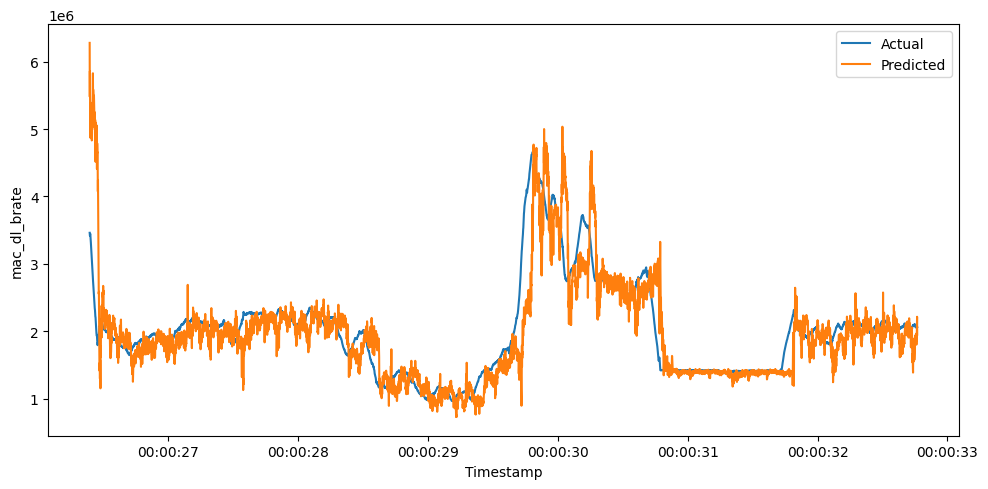

In [10]:
def inverse_transform_univariate_3d(data_3d, scaler):
    n_samples, horizon, n_channels = data_3d.shape
    data_2d = data_3d.reshape(-1, 1)
    data_inv = scaler.inverse_transform(data_2d)
    return data_inv.reshape(n_samples, horizon, 1)

y_test_original = inverse_transform_univariate_3d(y_test_uni, scaler_target)
y_pred_original = inverse_transform_univariate_3d(y_pred_scaled, scaler_target)

# average each forecast window
actual_window_avg = y_test_original[:, :, 0].mean(axis=1)
pred_window_avg = y_pred_original[:, :, 0].mean(axis=1)

# midpoint timestamp of each prediction window
window_time = [ts[len(ts)//2] for ts in test_dates]
window_time = pd.to_datetime(window_time)

plt.figure(figsize=(10, 5))
plt.plot(window_time, actual_window_avg, label='Actual')
plt.plot(window_time, pred_window_avg, label='Predicted')

plt.xlabel('Timestamp')
plt.ylabel(f'{target}')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
results_dir = Path("../results/metrics")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([{
    "model": "iTransformer",
    "setting": "univariate",
    "dataset": "youtube_static",
    "rmse": rmse_scaled,
    "mae": mae_scaled,
}])

metrics_file = results_dir / "itrans_uni_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)

print("Saved metrics to:", metrics_file)

Saved metrics to: ..\results\metrics\itrans_uni_metrics.csv
